<a href="https://colab.research.google.com/github/aumer1800/HeartDisease/blob/main/HeartDiseaseIndiactor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Upload Kaggle json file

In [ ]:
from google.colab import files
upload = files.upload()

Saving kaggle (2).json to kaggle (2).json


# Download dataset directly from kaggle

In [ ]:
# Install Kaggle if needed
!pip install -q kaggle

# Download the dataset
!kaggle datasets download -d kamilpytlak/personal-key-indicators-of-heart-disease

Dataset URL: https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease
License(s): CC0-1.0
personal-key-indicators-of-heart-disease.zip: Skipping, found more recently modified local copy (use --force to force download)


# Unzip the dataset

In [ ]:
import zipfile

with zipfile.ZipFile("personal-key-indicators-of-heart-disease.zip", "r") as zip_ref:
    zip_ref.extractall("heart-disease")

# Check the data struture

In [ ]:
import os
for root,dirs ,files in os.walk("heart-disease"):
  for file in files:
    print(os.path.join(root , file))

heart-disease/2020/heart_2020_cleaned.csv
heart-disease/2022/heart_2022_with_nans.csv
heart-disease/2022/heart_2022_no_nans.csv


# Load the dataset

In [ ]:
import pandas as pd
df = pd.read_csv("heart-disease/2022/heart_2022_no_nans.csv")

# Data Cleaning

In [ ]:
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,...,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [ ]:
df.shape

(246022, 40)

In [ ]:
df.isnull().sum()

,0
State,0
Sex,0
GeneralHealth,0
PhysicalHealthDays,0
MentalHealthDays,0
LastCheckupTime,0
PhysicalActivities,0
SleepHours,0
RemovedTeeth,0
HadHeartAttack,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246013 entries, 0 to 246021
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      246013 non-null  object 
 1   Sex                        246013 non-null  object 
 2   GeneralHealth              246013 non-null  object 
 3   PhysicalHealthDays         246013 non-null  float64
 4   MentalHealthDays           246013 non-null  float64
 5   LastCheckupTime            246013 non-null  object 
 6   PhysicalActivities         246013 non-null  object 
 7   SleepHours                 246013 non-null  float64
 8   RemovedTeeth               246013 non-null  object 
 9   HadHeartAttack             246013 non-null  object 
 10  HadAngina                  246013 non-null  object 
 11  HadStroke                  246013 non-null  object 
 12  HadAsthma                  246013 non-null  object 
 13  HadSkinCancer              246013 

In [ ]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


State
['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia'
 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming' 'Guam' 'Puerto Rico'
 'Virgin Islands']

Sex
['Female' 'Male']

GeneralHealth
['Very good' 'Fair' 'Good' 'Excellent' 'Poor']

PhysicalHealthDays
[ 4.  0.  5.  3.  2. 25. 30. 15. 29.  8. 16. 20. 10.  9.  7.  1. 21.  6.
 27. 14. 12. 11. 13. 28. 17. 23. 24. 26. 18. 22. 19.]

MentalHealthDays
[ 0. 15.  4. 25.  5. 30. 27.  3.  2.  1. 10. 20. 21.  6.  7.  8. 14.  9.
 12. 18. 29. 28. 17. 11. 1

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts())


State
State
Washington              14998
Maryland                 9163
Minnesota                9161
Ohio                     8995
New York                 8923
Texas                    7408
Florida                  7315
Kansas                   6145
Wisconsin                6126
Maine                    6013
Iowa                     5672
Hawaii                   5596
Virginia                 5565
Indiana                  5502
South Carolina           5471
Massachusetts            5465
Arizona                  5461
Utah                     5373
Michigan                 5370
Colorado                 5159
Nebraska                 5107
California               5096
Connecticut              5053
Georgia                  4978
Vermont                  4844
South Dakota             4404
Montana                  4264
Missouri                 4195
New Jersey               3966
New Hampshire            3756
Puerto Rico              3589
Idaho                    3468
Alaska                   32

In [ ]:
df['HadHeartAttack'].value_counts()

,count
HadHeartAttack,
No,232578
Yes,13435


# EDA

Numerical feature distribution

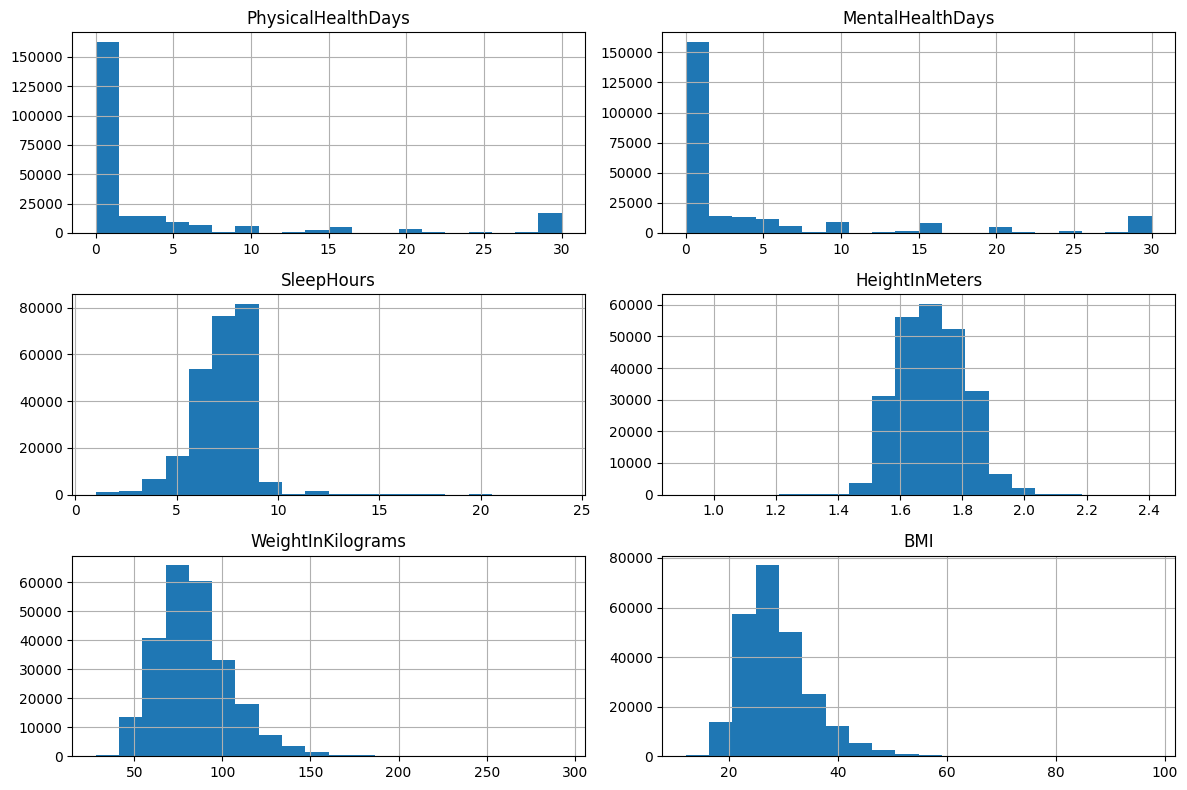

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

Correlation

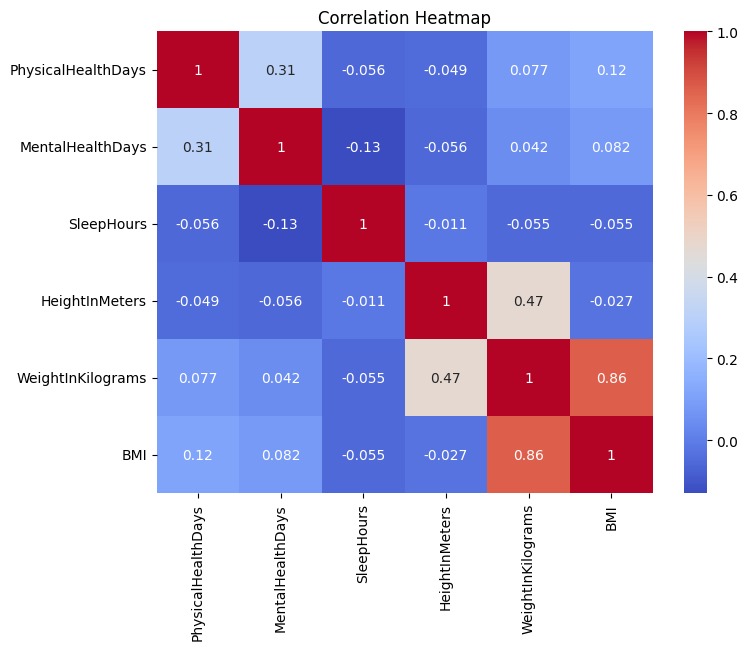

In [ ]:
plt.figure(figsize = (8,6))
sns.heatmap(df[numerical_cols].corr(),annot = True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Boxplots (Outlier Detection)

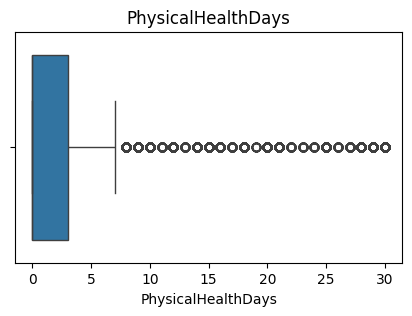

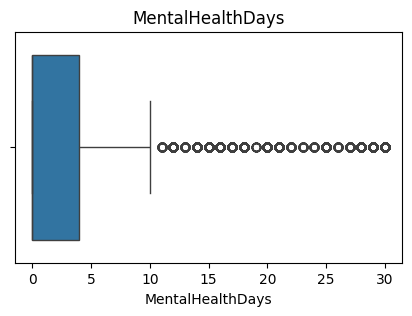

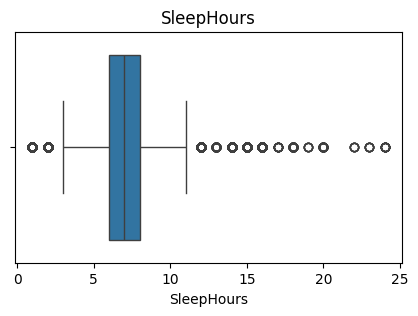

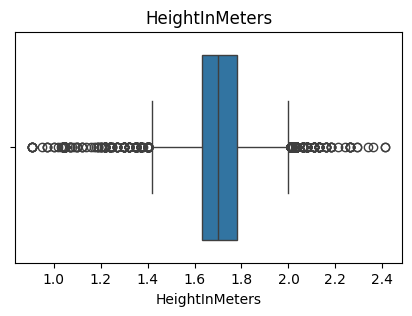

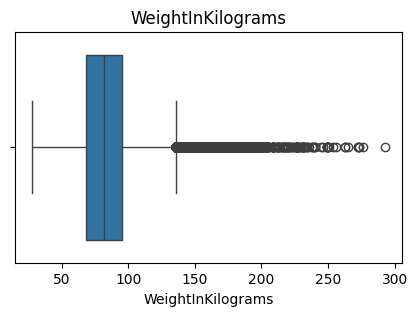

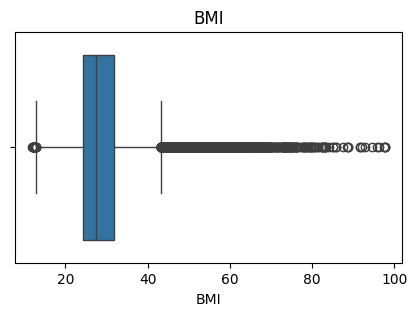

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Categorical Features vs Target

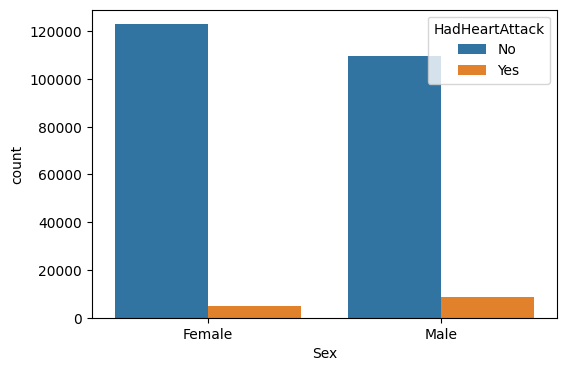

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='HadHeartAttack', data=df)
plt.show()

# Data Preprocessing.

Separate Features and Target

In [ ]:
x = df.drop("HadHeartAttack", axis = 1)
y = df["HadHeartAttack"]

Encode the variables

In [ ]:
# encode target column which is HadHeartDisease
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
# encode categorical columns
for col in x.select_dtypes(include = "object").columns:
  x[col]= LabelEncoder().fit_transform(x[col])

#Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test , y_train,y_test = train_test_split(x,y , test_size=0.2, random_state=42, stratify=y)
# preserves the class distribution in both sets.

# Model Selection

Handle Class Imbalance

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


Train Decision tree model

In [ ]:
dt = DecisionTreeClassifier(class_weight= "balanced" , random_state =42)
dt.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

Train Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Predict

In [ ]:
y_pred = dt.predict(x_test)

In [ ]:
rf_pred = rf.predict(x_test)

Evaluate the model

In [ ]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score , confusion_matrix)
from sklearn.metrics import ConfusionMatrixDisplay
print("Accuracy : ", accuracy_score(y_test , y_pred))
print("f1_score : ", f1_score(y_test , y_pred))
print("precision_score : ", precision_score(y_test , y_pred))
print("recall_score : ", recall_score(y_test , y_pred))


Accuracy :  0.9212243155905128
f1_score :  0.25889101338432124
precision_score :  0.266220998820291
recall_score :  0.25195385187941943


In [ ]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.9476251448082434
Precision: 0.5992779783393501
Recall   : 0.12355787123185709
F1 Score : 0.2048750385683431


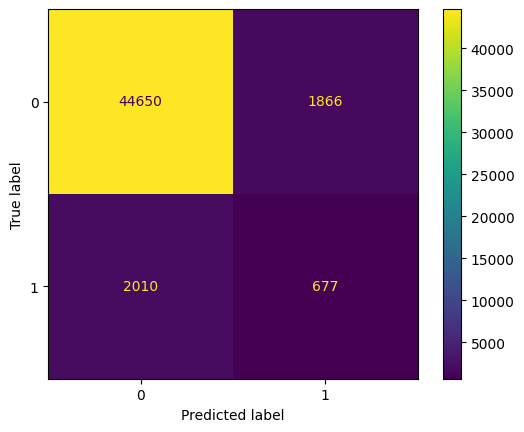

In [ ]:
ConfusionMatrixDisplay.from_estimator(dt, x_test , y_test )

# Apply Smote with RandomForest

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(x_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
0    186062
1     10748
Name: count, dtype: int64

After SMOTE:
0    186062
1    186062
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Predictions
y_pred = rf.predict(x_test)

# Probability scores (for ROC-AUC)
y_prob = rf.predict_proba(x_test)[:, 1]

print("=" * 40)
print("Random Forest + SMOTE")
print("=" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Random Forest + SMOTE
Accuracy : 0.925898827307278
Precision: 0.32844364937388193
Recall   : 0.3416449572013398
F1 Score : 0.3349142648668369
ROC-AUC  : 0.8478821794249666

Confusion Matrix
[[44639  1877]
 [ 1769   918]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     46516
           1       0.33      0.34      0.33      2687

    accuracy                           0.93     49203
   macro avg       0.65      0.65      0.65     49203
weighted avg       0.93      0.93      0.93     49203



In [ ]:
print(df.columns)

Index(['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays',
       'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities',
       'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina',
       'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory',
       'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers',
       'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap',
       'HighRiskLastYear', 'CovidPos'],
      dtype='object')


In [ ]:
x_test.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadAngina,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
69282,17,1,4,0.0,4.0,3,1,6.0,2,0,...,1.70,58.97,20.36,1,0,1,0,2,0,0
9340,2,1,2,0.0,0.0,3,1,7.0,3,0,...,1.75,77.11,25.10,1,1,1,1,1,0,0
42145,10,1,2,0.0,0.0,3,1,4.0,3,0,...,1.57,111.58,44.99,0,0,0,0,1,0,2
129326,28,1,2,2.0,0.0,3,1,8.0,0,0,...,1.85,122.47,35.62,1,0,1,0,2,0,0
143270,33,1,1,15.0,20.0,3,0,6.0,1,0,...,1.65,61.23,22.46,1,1,1,0,2,0,2


In [ ]:
x_test.columns

Index(['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays',
       'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities',
       'SleepHours', 'RemovedTeeth', 'HadAngina', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease',
       'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing',
       'BlindOrVisionDifficulty', 'DifficultyConcentrating',
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands',
       'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object')

Enter data to check model working.

In [ ]:
import pandas as pd

user_input = pd.DataFrame({
    "State": [17],
    "Sex": [1],
    "GeneralHealth": [4],
    "PhysicalHealthDays": [0.0],
    "MentalHealthDays": [4.0],
    "LastCheckupTime": [3],
    "PhysicalActivities": [1],
    "SleepHours": [6.0],
    "RemovedTeeth": [2],
    "HadAngina": [0],
    "HadStroke": [0],
    "HadAsthma": [0],
    "HadSkinCancer": [0],
    "HadCOPD": [0],
    "HadDepressiveDisorder": [0],
    "HadKidneyDisease": [0],
    "HadArthritis": [0],
    "HadDiabetes": [0],
    "DeafOrHardOfHearing": [0],
    "BlindOrVisionDifficulty": [0],
    "DifficultyConcentrating": [0],
    "DifficultyWalking": [0],
    "DifficultyDressingBathing": [0],
    "DifficultyErrands": [0],
    "SmokerStatus": [0],
    "ECigaretteUsage": [0],
    "ChestScan": [0],
    "RaceEthnicityCategory": [0],
    "AgeCategory": [0],
    "HeightInMeters": [1.70],
    "WeightInKilograms": [58.97],
    "BMI": [20.36],
    "AlcoholDrinkers": [1],
    "HIVTesting": [0],
    "FluVaxLast12": [1],
    "PneumoVaxEver": [0],
    "TetanusLast10Tdap": [2],
    "HighRiskLastYear": [0],
    "CovidPos": [0]
})

prediction = rf.predict(user_input)[0]
probability = rf.predict_proba(user_input)[0]

print("Prediction:", prediction)
print("Probability of Class 0:", probability[0])
print("Probability of Class 1:", probability[1])

Prediction: 0
Probability of Class 0: 0.8166666666666667
Probability of Class 1: 0.18333333333333332


Compare Predicted and Actual output

In [ ]:
sample = x_test.iloc[[0]]

prediction = rf.predict(sample)[0]

print("Predicted:", prediction)
print("Actual   :", y_test[0])

Predicted: 0
Actual   : 0
